# Angle Conversion Inspection

This notebook loads the CSV generated by `angle_conversion_export` and plots the input and output angles for visual inspection.

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

# Resolve paths relative to this notebook's location
notebook_dir = Path('.').resolve()
data_dir = notebook_dir.parent / 'data'

csv_path = data_dir / 'angle_conversion_export.csv'
if not csv_path.exists():
    print(f"File not found: {csv_path}")
    print(f"Working from: {notebook_dir}")
else:
    df = pd.read_csv(csv_path)
    df.head()

In [2]:
# Print dimensions of the dataframe
print(f"Dataframe dimensions: {df.shape}")

Dataframe dimensions: (800, 13)


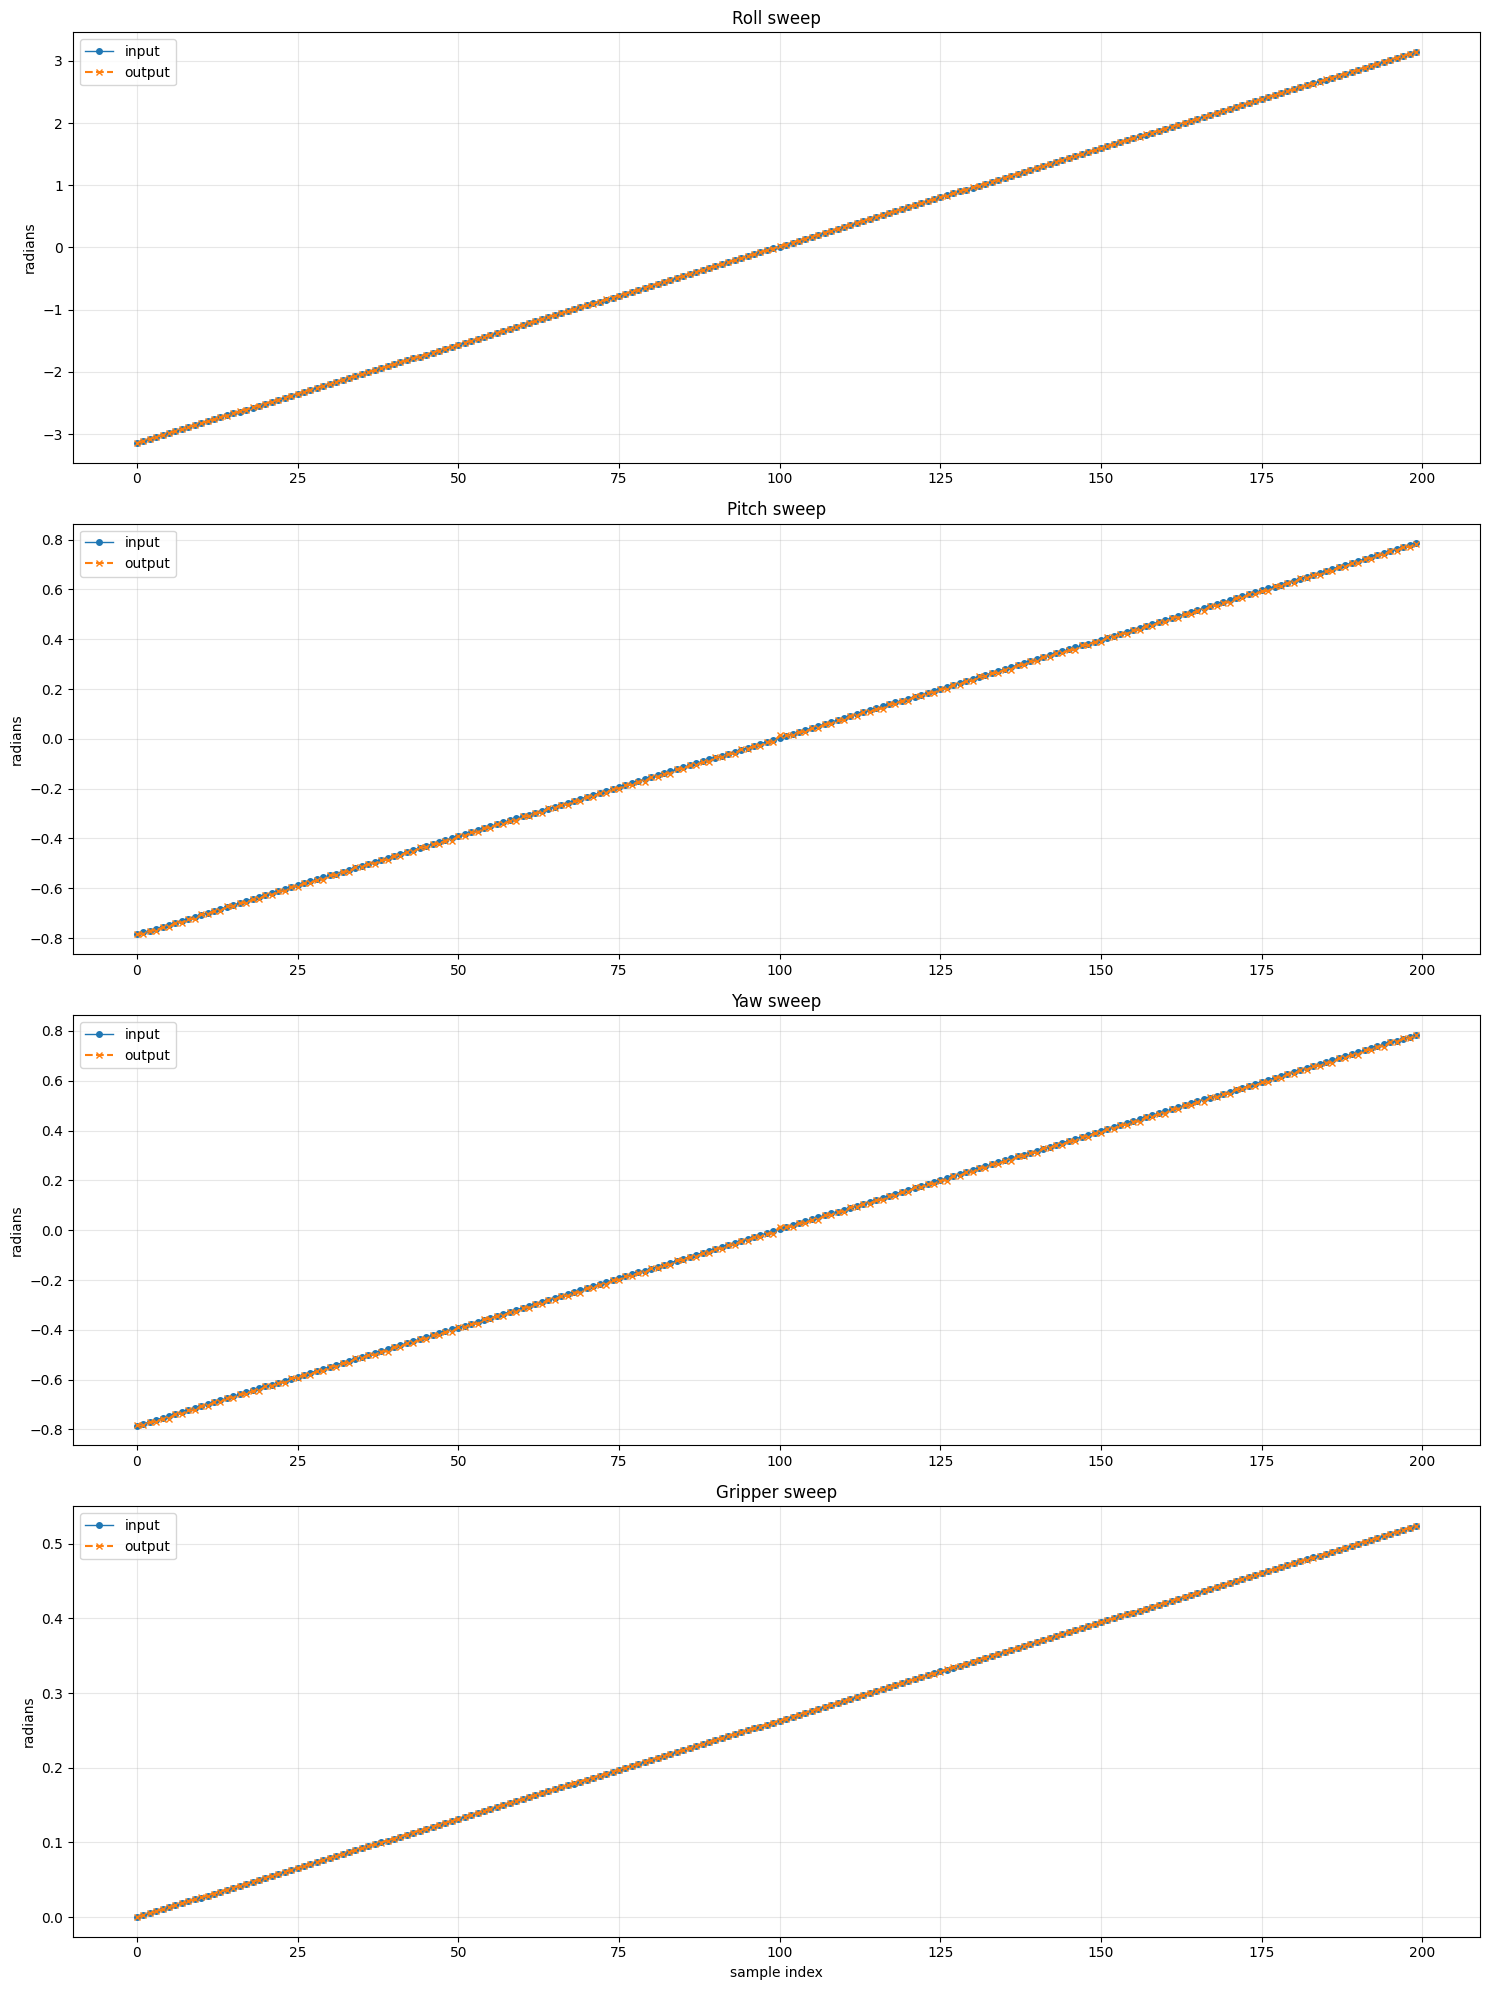

In [3]:
axis_names = ['roll', 'pitch', 'yaw', 'gripper']
angle_columns = ['roll', 'pitch', 'yaw', 'gripper']

fig, axes = plt.subplots(4, 1, figsize=(15, 20), sharex=False)

for axis_index, axis_name in enumerate(axis_names):
    subset = df[df['sweep_axis'] == axis_name].reset_index(drop=True)
    x = subset.index
    # plot lines and points
    axes[axis_index].plot(x, subset[f'input_{axis_name}'], label='input', linewidth=1, marker='o', markersize=4)
    axes[axis_index].plot(x, subset[f'output_{axis_name}'], label='output', linestyle='--',marker='x', markersize=4)
    axes[axis_index].set_title(f'{axis_name.capitalize()} sweep')
    axes[axis_index].set_ylabel('radians')
    axes[axis_index].grid(True, alpha=0.3)
    axes[axis_index].legend()

axes[-1].set_xlabel('sample index')
plt.tight_layout()
plt.show()

In [4]:
df['max_abs_error'] = (df[[f'input_{c}' for c in angle_columns]] - df[[f'output_{c}' for c in angle_columns]]).abs().max(axis=1)
df[['sweep_axis', 'max_abs_error']].groupby('sweep_axis').describe()

max_abs_error                             
                   count mean std min 25% 50% 75% max
sweep_axis                                           
gripper              0.0  NaN NaN NaN NaN NaN NaN NaN
pitch                0.0  NaN NaN NaN NaN NaN NaN NaN
roll                 0.0  NaN NaN NaN NaN NaN NaN NaN
yaw                  0.0  NaN NaN NaN NaN NaN NaN NaN

## Joint Angle Conversion (Sinusoidal Sweeps)

Load and plot the joint-angle exporter output, which drives each DOF with a sinusoidal sweep (0 to π/4 over one cycle).

In [5]:
joint_csv_path = data_dir / 'joint_angle_conversion_export.csv'
# Adjust path if needed (e.g., /tmp/joint_angle_conversion_export.csv)
if not joint_csv_path.exists():
    print(f"File not found: {joint_csv_path}")
    print(f"Run: ./build/adlap_tool_control/joint_angle_conversion_export --output {joint_csv_path}")
else:
    df_joint = pd.read_csv(joint_csv_path)
    print(f"Loaded {len(df_joint)} rows from {joint_csv_path}")
    df_joint.head()

Loaded 2000 rows from /home/roel/ws_moveit/src/adlap_tool_control/data/joint_angle_conversion_export.csv


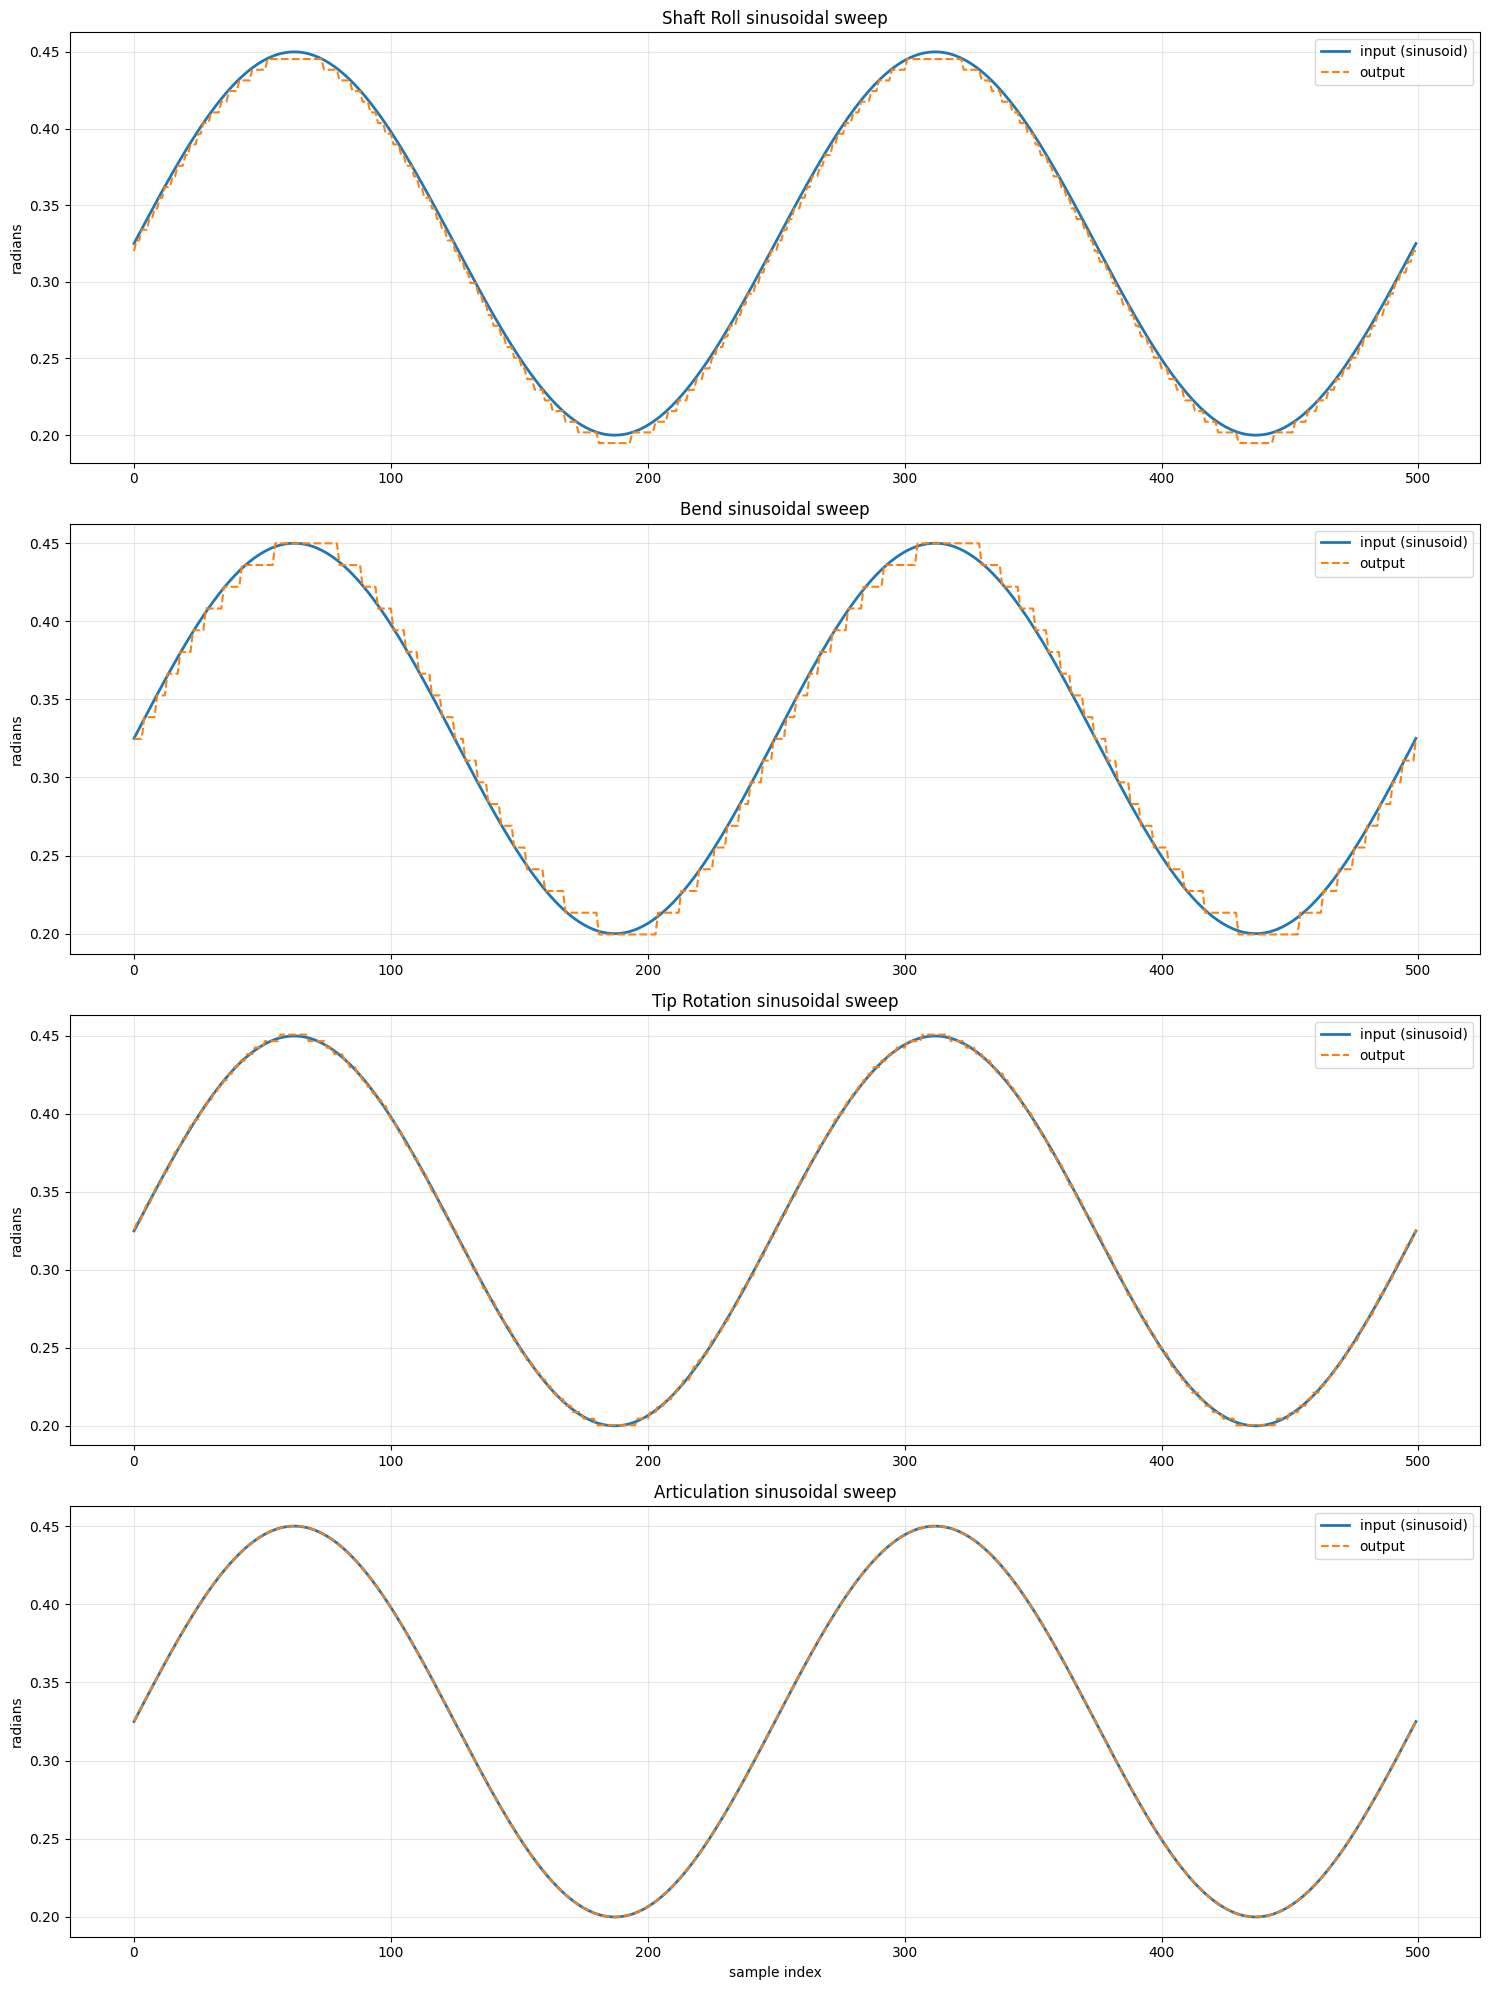

In [6]:
joint_axis_names = ['shaft_roll', 'bend', 'tip_rotation', 'articulation']

fig, axes = plt.subplots(4, 1, figsize=(15, 20), sharex=False)

for axis_index, axis_name in enumerate(joint_axis_names):
    subset = df_joint[df_joint['sweep_axis'] == axis_name].reset_index(drop=True)
    x = subset.index

    axes[axis_index].plot(x, subset[f'input_{axis_name}'], label='input (sinusoid)', linewidth=2)
    axes[axis_index].plot(x, subset[f'output_{axis_name}'], label='output', linestyle='--')
    axes[axis_index].set_title(f'{axis_name.replace("_", " ").title()} sinusoidal sweep')
    axes[axis_index].set_ylabel('radians')
    axes[axis_index].grid(True, alpha=0.3)
    axes[axis_index].legend()

axes[-1].set_xlabel('sample index')
plt.tight_layout()
plt.show()